<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Sentinel_Influence_RAPPORT_AlexZanBi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOC 1 — Chargement et nettoyage des posts Facebook
# ============================================================
# POURQUOI : construire le DataFrame de reference des posts pour
# calculer les KPIs d'engagement (commentaires, reactions, partages)
# et identifier les contenus les plus viraux.
# COMMENT : on charge l'export Apify, on ne garde que les colonnes
# utiles, et on calcule les metriques d'engagement.

import pandas as pd
import numpy as np
from google.colab import files

# --- Charger le fichier posts ---
print("Selectionne le fichier CSV/Excel des posts Facebook :")
uploaded = files.upload()
nom_fichier = list(uploaded.keys())[0]

if nom_fichier.endswith(".xlsx"):
    df_posts_brut = pd.read_excel(nom_fichier)
elif nom_fichier.endswith(".csv"):
    df_posts_brut = pd.read_csv(nom_fichier)
else:
    df_posts_brut = pd.read_json(nom_fichier)

print(f"\n{df_posts_brut.shape[0]} posts charges, {df_posts_brut.shape[1]} colonnes")

# --- Garder les colonnes utiles ---
colonnes_utiles = ["text", "time", "timestamp", "url", "facebookUrl",
                   "comments", "likes", "shares", "topReactionsCount",
                   "reactionLikeCount", "reactionLoveCount", "reactionHahaCount",
                   "reactionWowCount", "reactionSadCount", "reactionAngryCount",
                   "reactionCareCount", "isVideo", "videoPostViewCount",
                   "viewsCount", "pageName", "postId"]
colonnes_presentes = [c for c in colonnes_utiles if c in df_posts_brut.columns]
posts_df = df_posts_brut[colonnes_presentes].copy()

# --- Convertir les types ---
for col in ["comments", "likes", "shares"]:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors="coerce").fillna(0).astype(int)

posts_df["date"] = pd.to_datetime(posts_df["time"], errors="coerce")

# --- Statistiques globales ---
print(f"\n{'='*50}")
print(f"STATISTIQUES GLOBALES — POSTS")
print(f"{'='*50}")
print(f"Total posts           : {len(posts_df)}")
print(f"Total commentaires    : {posts_df['comments'].sum():,}")
print(f"Total reactions       : {posts_df['likes'].sum():,}")
print(f"Total partages        : {posts_df['shares'].sum():,}")
print(f"Moyenne commentaires  : {posts_df['comments'].mean():.1f} / post")
print(f"Moyenne reactions     : {posts_df['likes'].mean():.1f} / post")
if "isVideo" in posts_df.columns:
    print(f"Posts video/reel      : {posts_df['isVideo'].sum()}")

posts_df.head()

Selectionne le fichier CSV/Excel des posts Facebook :


Saving dataset_facebook-posts-scraper_2026-07-01_22-11-31-700.csv to dataset_facebook-posts-scraper_2026-07-01_22-11-31-700 (1).csv

100 posts charges, 536 colonnes

STATISTIQUES GLOBALES — POSTS
Total posts           : 100
Total commentaires    : 9,151
Total reactions       : 122,414
Total partages        : 2,171
Moyenne commentaires  : 91.5 / post
Moyenne reactions     : 1224.1 / post
Posts video/reel      : 48


,text,time,timestamp,url,facebookUrl,comments,likes,shares,topReactionsCount,reactionLikeCount,...,reactionWowCount,reactionSadCount,reactionAngryCount,reactionCareCount,isVideo,videoPostViewCount,viewsCount,pageName,postId,date
0,NaN,2026-07-01T21:36:19.000Z,1782941779,https://www.facebook.com/reel/1193333669605585/,https://www.facebook.com/astephbi,6,86,0,4,79,...,1.0,NaN,NaN,2.0,True,297.0,768.0,astephbi,26572965932378079,2026-07-01 21:36:19+00:00
1,NaN,2026-07-01T19:16:49.000Z,1782933409,https://www.facebook.com/reel/2523075728105458/,https://www.facebook.com/astephbi,1,167,5,2,159,...,NaN,NaN,NaN,NaN,True,1469.0,2988.0,astephbi,26571932269148112,2026-07-01 19:16:49+00:00
2,"cool à regarder, non ?",2026-07-01T18:55:01.000Z,1782932101,https://www.facebook.com/reel/1728315921757269/,https://www.facebook.com/astephbi,30,1014,17,5,976,...,3.0,NaN,NaN,5.0,True,21876.0,35831.0,astephbi,26567873852887287,2026-07-01 18:55:01+00:00
3,"Alex à VIVATECH Paris, c’est pas encore fini 💪...",2026-07-01T17:53:04.000Z,1782928384,https://www.facebook.com/reel/1371148338249672/,https://www.facebook.com/astephbi,1,78,0,2,74,...,NaN,NaN,NaN,NaN,True,737.0,2091.0,astephbi,26571253765882629,2026-07-01 17:53:04+00:00
4,NaN,2026-07-01T15:19:31.000Z,1782919171,https://www.facebook.com/reel/2253010578779709/,https://www.facebook.com/astephbi,26,1043,8,5,917,...,2.0,NaN,NaN,3.0,True,6487.0,12294.0,astephbi,26569906876017318,2026-07-01 15:19:31+00:00


In [2]:
# ============================================================
# BLOC 2 — Top 20 posts les plus commentes + extraction URLs
# ============================================================
# POURQUOI : on concentre l'analyse NLP sur les posts a fort
# engagement car c'est la que se trouvent les opinions les plus
# riches (fans actifs ET critiques).
# COMMENT : tri par nombre de commentaires, extraction des URLs,
# separation posts classiques / reels (les reels peuvent necessiter
# un login Facebook pour le scraping des commentaires).

top_20 = posts_df.nlargest(20, "comments")

print(f"{'='*70}")
print(f"TOP 20 POSTS LES PLUS COMMENTES")
print(f"{'='*70}")

for i, (_, row) in enumerate(top_20.iterrows(), 1):
    txt = str(row.get("text", ""))[:80].replace("\n", " ")
    if txt == "nan":
        txt = "[Reel video]"
    url = row.get("url") or row.get("facebookUrl", "")
    date_str = str(row.get("time", ""))[:10]
    print(f"\n{i:2d}. [{row['comments']} com | {row['likes']} likes | {row['shares']} shares] {date_str}")
    print(f"    {txt}...")
    print(f"    URL: {url}")

# --- Separer posts classiques vs reels ---
col_url = "url" if "url" in top_20.columns else "facebookUrl"
urls_all = top_20[col_url].dropna().tolist()

posts_urls = [u for u in urls_all if "/posts/" in str(u)]
reels_urls = [u for u in urls_all if "/reel/" in str(u)]

print(f"\n{'='*70}")
print(f"POSTS classiques : {len(posts_urls)} (scraping direct)")
print(f"REELS             : {len(reels_urls)} (peut necessiter login FB)")
print(f"{'='*70}")

# --- Afficher les URLs a copier dans Apify Comments Scraper ---
print(f"\n--- COPIE CES URLs DANS APIFY FACEBOOK COMMENTS SCRAPER ---\n")
for url in posts_urls:
    print(url)

print(f"\n--- REELS (essaie aussi) ---\n")
for url in reels_urls:
    print(url)

# --- Sauvegarder ---
with open("top20_urls.txt", "w") as f:
    for u in urls_all:
        f.write(str(u) + "\n")

posts_df.to_csv("posts_clean.csv", index=False)
print(f"\nFichier sauvegarde : top20_urls.txt et posts_clean.csv")

TOP 20 POSTS LES PLUS COMMENTES

 1. [1719 com | 3573 likes | 429 shares] 2026-06-27
    800.000 FCFA de salaire à Abidjan ou 1.500 euros en France ?  Tu choisis quoi ?...
    URL: https://www.facebook.com/astephbi/posts/pfbid02wXRfatUdt5sQuTNiPGTxdu4h7TGbLNWePY18VQbUkt2mfGVqbk44r8hohDCu2xsMl

 2. [670 com | 7898 likes | 115 shares] 2026-06-22
    [Reel video]...
    URL: https://www.facebook.com/reel/1301058525089117/

 3. [423 com | 1482 likes | 36 shares] 2026-06-25
    Quelqu’un a déjà atteint cette vitesse de connexion à Abidjan ?  Je suis curieux...
    URL: https://www.facebook.com/astephbi/posts/pfbid0ePWJ9dXvDtcq5tqkexD8sawBi1Lke2YpWbbxqu5SsPVW9Mp3pm7UP62zMYkbjpUvl

 4. [399 com | 1931 likes | 66 shares] 2026-06-25
    Tu préfères 600k par mois avec voiture de service ou 1.000.000 sans rien d’autre...
    URL: https://www.facebook.com/astephbi/posts/pfbid032EEVGPSknmDBuVXNF9ne3Z8FGkXDup8zrVAYwJZfPUFfA6NDX6MZasshA6giG5STl

 5. [274 com | 5736 likes | 59 shares] 2026-06-23
    J

In [3]:
# ============================================================
# BLOC 3 — Charger et nettoyer les commentaires Facebook
# ============================================================
# POURQUOI : construire le DataFrame de commentaires exploitable
# pour l'analyse NLP (sentiment + themes).
# COMMENT : on charge l'export Apify Comments Scraper, on garde
# les colonnes utiles, et on exclut les commentaires de
# l'influenceur lui-meme (on veut analyser SA communaute).

print("Selectionne le fichier CSV/Excel des commentaires :")
uploaded_comments = files.upload()
nom_fichier_com = list(uploaded_comments.keys())[0]

if nom_fichier_com.endswith(".xlsx"):
    df_comments_brut = pd.read_excel(nom_fichier_com)
elif nom_fichier_com.endswith(".csv"):
    df_comments_brut = pd.read_csv(nom_fichier_com)
else:
    df_comments_brut = pd.read_json(nom_fichier_com)

print(f"{df_comments_brut.shape[0]} commentaires charges\n")

# --- Garder les colonnes utiles ---
cols_comments = ["text", "date", "profileName", "likesCount",
                 "threadingDepth", "postTitle", "inputUrl", "commentId"]
cols_present = [c for c in cols_comments if c in df_comments_brut.columns]
comments_df = df_comments_brut[cols_present].copy()

# --- Nettoyage ---
comments_df["date"] = pd.to_datetime(comments_df["date"], errors="coerce")
comments_df["likesCount"] = pd.to_numeric(comments_df.get("likesCount", 0), errors="coerce").fillna(0).astype(int)
comments_df["threadingDepth"] = pd.to_numeric(comments_df.get("threadingDepth", 0), errors="coerce").fillna(0).astype(int)

# --- Filtrer : garder les commentaires avec texte, exclure l'influenceur ---
# ⚠️ ADAPTE le nom ci-dessous au profil que tu analyses
NOM_INFLUENCEUR = "Alex Zan Bi"

comments_avec_texte = comments_df[
    comments_df["text"].notna() &
    (comments_df["text"].str.strip() != "") &
    (comments_df["profileName"] != NOM_INFLUENCEUR)
].copy()

print(f"{'='*50}")
print(f"STATISTIQUES COMMENTAIRES")
print(f"{'='*50}")
print(f"Total brut             : {len(df_comments_brut)}")
print(f"Avec texte (hors Alex) : {len(comments_avec_texte)}")
print(f"Top-level (depth=0)    : {(comments_avec_texte['threadingDepth']==0).sum()}")
print(f"Reponses (depth>0)     : {(comments_avec_texte['threadingDepth']>0).sum()}")
print(f"Commentateurs uniques  : {comments_avec_texte['profileName'].nunique()}")

comments_avec_texte.head()

Selectionne le fichier CSV/Excel des commentaires :


Saving dataset_facebook-comments-scraper_2026-07-01_22-32-54-356.csv to dataset_facebook-comments-scraper_2026-07-01_22-32-54-356 (1).csv
1328 commentaires charges

STATISTIQUES COMMENTAIRES
Total brut             : 1328
Avec texte (hors Alex) : 1314
Top-level (depth=0)    : 542
Reponses (depth>0)     : 772
Commentateurs uniques  : 959


,text,date,profileName,likesCount,threadingDepth,postTitle,inputUrl,commentId
2,Très philosophique 😂\nKO himra chante rien de ...,2026-06-23 09:10:37+00:00,Abdoulaye Sékongo,55,0,J’suis l’ivoirien le plus influent donc j’ai r...,https://www.facebook.com/astephbi/posts/pfbid0...,2482299392233890
3,La djandjou est bonne mais quand je pense à ma...,2026-06-23 09:26:28+00:00,Kouakou Florent,51,0,J’suis l’ivoirien le plus influent donc j’ai r...,https://www.facebook.com/astephbi/posts/pfbid0...,990299977102760
4,Il fallait avoir l'oreille musicale pour compr...,2026-06-23 09:13:04+00:00,West Monney,25,0,J’suis l’ivoirien le plus influent donc j’ai r...,https://www.facebook.com/astephbi/posts/pfbid0...,4449766738639698
5,Faut avoir un air musical pour comprendre 🤣🤣,2026-06-23 09:26:24+00:00,Konan Timothée Yao,15,0,J’suis l’ivoirien le plus influent donc j’ai r...,https://www.facebook.com/astephbi/posts/pfbid0...,1330898272512146
6,"Écrire à l'origine, c'est plonger une plume da...",2026-06-23 18:06:39+00:00,Agate Palakiyem Josué,5,0,J’suis l’ivoirien le plus influent donc j’ai r...,https://www.facebook.com/astephbi/posts/pfbid0...,1749785336337761


In [8]:
# ============================================================
# BLOC 4 — Analyse de sentiment (grille 6 categories influenceur)
# ============================================================
# POURQUOI : la grille Positif/Neutre/Negatif est trop simpliste
# pour un influenceur. "Neutre" cache 60% des signaux utiles.
# On eclate en 6 categories actionnables :
#   - Fan/Soutien    : le commentateur soutient l'influenceur
#   - Debat/Opinion  : il donne son avis argumente sur le sujet
#   - Humour/Banter  : blagues, emojis rire, complicite
#   - Question        : demande d'info, curiosite
#   - Tag/Partage    : mentionne un ami, amplifie le contenu
#   - Critique/Hater : desaccord, attaque, negativite
# COMMENT : BERT donne le score brut (1-5), puis un dictionnaire
# lexical affine la categorie parmi les 6.

!pip install transformers torch -q

from transformers import pipeline
import warnings, re
warnings.filterwarnings("ignore")

print("Chargement du modele BERT multilingue...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512
)
print("Modele charge.\n")

# --- Dictionnaires de detection par categorie ---
PATTERNS_FAN = {
    "bravo", "merci", "top", "super", "excellent", "magnifique", "respect",
    "fier", "fierté", "courage", "force", "inspirant", "motivant", "boss",
    "legend", "légende", "king", "champion", "mentor", "modèle", "modele",
    "chapeau", "patron", "le boss", "bénédiction", "félicitations",
    "j'adore", "tu gères", "tu geres", "on est là", "on est la",
    "great", "amazing", "best", "love", "proud", "wonderful",
    "👏", "💪", "🔥", "❤", "🙏", "👍", "💯", "🫡", "👑", "🏆"
}

PATTERNS_HUMOUR = {
    "mdr", "mdrrr", "lol", "ptdr", "mort de rire", "je pleure",
    "trop drôle", "trop drole", "haha", "hihi", "😂", "🤣", "😆",
    "😭", "💀", "askip", "wallah", "c'est chaud", "deh", "gbê",
    "j'ai ri", "jai ri", "tu m'as tué", "tu mas tue", "je suis mort",
    "🤡", "😹", "looool", "ahahah", "rofl"
}

PATTERNS_QUESTION = {
    "comment", "pourquoi", "c'est quoi", "c quoi", "ça veut dire",
    "ca veut dire", "tu peux expliquer", "quelqu'un peut", "help",
    "svp", "s'il vous", "stp", "?", "how", "what", "why", "where",
    "est-ce que", "est ce que", "tu fais comment", "ça marche comment",
    "je comprends pas", "je ne comprends"
}

PATTERNS_TAG = {
    "regarde", "viens voir", "cc", "tiens", "check", "look",
    "t'as vu", "tas vu", "venez voir", "faut voir"
}

PATTERNS_CRITIQUE = {
    "nul", "faux", "menteur", "arnaque", "arnaqueur", "honte",
    "ridicule", "n'importe quoi", "nimporte quoi", "bêtise",
    "idiot", "stupide", "mauvais", "horrible", "médiocre",
    "fake", "clown", "bouffon", "mytho", "mensonge", "prétentieux",
    "tu mens", "c'est faux", "fatiguant", "on s'en fout",
    "ça sert à rien", "tais-toi", "ferme", "😡", "👎", "🤮",
    "trash", "nonsense", "bullshit", "scam", "worst"
}

def has_tag_mention(text):
    """Detecte si le commentaire mentionne/tague quelqu'un."""
    # Pattern Facebook : noms propres tagges ou "@"
    if "@" in text:
        return True
    # Quand on tague sur FB le nom apparait en majuscule ou avec des patterns specifiques
    if re.search(r'[A-Z][a-z]+ [A-Z][a-z]+', text) and len(text) < 80:
        # Court commentaire avec un nom propre = probablement un tag
        tag_words = [w for w in PATTERNS_TAG if w in text.lower()]
        if tag_words:
            return True
    return False

def classifier_6_categories(texte):
    """Classifie un commentaire en 6 categories."""
    try:
        t = str(texte)[:512]
        t_lower = t.lower()

        # --- Score BERT (base) ---
        resultat = sentiment_pipeline(t)[0]
        note_bert = int(resultat["label"][0])  # 1 a 5
        confiance = round(resultat["score"], 3)

        # --- Comptage par categorie ---
        score_fan      = sum(1 for m in PATTERNS_FAN if m in t_lower or m in t)
        score_humour   = sum(1 for m in PATTERNS_HUMOUR if m in t_lower or m in t)
        score_question = sum(1 for m in PATTERNS_QUESTION if m in t_lower)
        score_critique = sum(1 for m in PATTERNS_CRITIQUE if m in t_lower or m in t)
        is_tag         = has_tag_mention(t)

        # --- Decision hierarchique ---
        # Priorite 1 : Critique forte (BERT negatif + mots critiques)
        if note_bert <= 2 and score_critique > 0:
            return "Critique", note_bert, confiance
        if score_critique >= 2:
            return "Critique", note_bert, confiance

        # Priorite 2 : Fan/Soutien (BERT positif + mots de soutien)
        if score_fan >= 2:
            return "Fan", note_bert, confiance
        if note_bert >= 4 and score_fan >= 1:
            return "Fan", note_bert, confiance

        # Priorite 3 : Humour (emojis rire, "mdr", etc.)
        if score_humour >= 1:
            return "Humour", note_bert, confiance

        # Priorite 4 : Question
        if score_question >= 1 and "?" in t:
            return "Question", note_bert, confiance

        # Priorite 5 : Tag/Partage
        if is_tag and len(t) < 100:
            return "Tag", note_bert, confiance

        # Priorite 6 : Debat (commentaire argumente, ni fan ni critique)
        if len(t) > 80 and note_bert == 3:
            return "Debat", note_bert, confiance
        if note_bert == 3:
            return "Debat", note_bert, confiance

        # Default par score BERT
        if note_bert >= 4:
            return "Fan", note_bert, confiance
        if note_bert <= 2:
            return "Critique", note_bert, confiance
        return "Debat", note_bert, confiance

    except Exception:
        return "Debat", None, None

# --- Application ---
print("Analyse de sentiment (6 categories) en cours...")
resultats = comments_avec_texte["text"].apply(classifier_6_categories)
comments_avec_texte["sentiment_label"] = resultats.apply(lambda x: x[0])
comments_avec_texte["sentiment_score"] = resultats.apply(lambda x: x[1])
comments_avec_texte["sentiment_confiance"] = resultats.apply(lambda x: x[2])

print("Analyse terminee.\n")
print("Repartition des 6 categories :")
print(comments_avec_texte["sentiment_label"].value_counts())

pct = comments_avec_texte["sentiment_label"].value_counts(normalize=True) * 100
print(f"\nEn pourcentage :")
for cat, val in pct.items():
    print(f"  {cat:12s}: {val:.1f}%")

comments_avec_texte[["profileName", "sentiment_label", "text"]].head(15)

Chargement du modele BERT multilingue...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modele charge.

Analyse de sentiment (6 categories) en cours...
Analyse terminee.

Repartition des 6 categories :
sentiment_label
Critique    350
Fan         342
Debat       264
Humour      206
Question    142
Tag          10
Name: count, dtype: int64

En pourcentage :
  Critique    : 26.6%
  Fan         : 26.0%
  Debat       : 20.1%
  Humour      : 15.7%
  Question    : 10.8%
  Tag         : 0.8%


,profileName,sentiment_label,text
2,Abdoulaye Sékongo,Humour,Très philosophique 😂\nKO himra chante rien de ...
3,Kouakou Florent,Debat,La djandjou est bonne mais quand je pense à ma...
4,West Monney,Debat,Il fallait avoir l'oreille musicale pour compr...
5,Konan Timothée Yao,Humour,Faut avoir un air musical pour comprendre 🤣🤣
6,Agate Palakiyem Josué,Humour,"Écrire à l'origine, c'est plonger une plume da..."
7,Onacam Mehiko,Critique,L’itinéraire est recalculé
8,Daniel Aby,Humour,Il avait déjà tout dit 🤣🤣
9,Trésor d'Afrique,Fan,la punchline des vacances 2026
10,N'cho Dorian,Humour,On avait un vieux père qui vendait les codes 😂😂
11,Wilherm Wk,Critique,"Cheat codes pour faire apparaître bateaux, hél..."


In [9]:
# ============================================================
# BLOC 5 — Classification thematique zero-shot (influenceur)
# ============================================================
# POURQUOI : identifier les sujets qui font reagir la communaute.
# Les labels sont adaptes a un profil influenceur tech/business
# (pas les memes que pour un restaurant).
# COMMENT : mDeBERTa-v3 en zero-shot avec des labels en francais.
# multi_label=True car un commentaire peut parler de tech ET
# d'entrepreneuriat en meme temps.

from transformers import pipeline

print("Chargement du modele de classification thematique...")
classifier_theme = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0   # mettre -1 si pas de GPU
)
print("Modele charge.\n")

# --- Labels adaptes a un influenceur tech/business ---
labels_influenceur = [
    "Tech et Intelligence Artificielle",
    "Afrique et Diaspora",
    "Entrepreneuriat et Business",
    "Motivation et Developpement personnel",
    "Societe et Culture"
]

def classer_themes_influenceur(texte, seuil=0.35):
    """Retourne les themes au-dessus du seuil."""
    try:
        resultat = classifier_theme(
            str(texte)[:512],
            candidate_labels=labels_influenceur,
            hypothesis_template="Ce commentaire parle de {}.",
            multi_label=True
        )
        themes_retenus = [
            label for label, score in zip(resultat["labels"], resultat["scores"])
            if score >= seuil
        ]
        if not themes_retenus:
            themes_retenus = [resultat["labels"][0]]
        return themes_retenus
    except Exception:
        return ["Non classe"]

# --- Application (5-10 min en CPU, 2-3 min en GPU) ---
print("Classification thematique en cours (patience, ~5-10 min)...")
comments_avec_texte["themes"] = comments_avec_texte["text"].apply(classer_themes_influenceur)
print("Classification terminee.\n")

# --- Frequence des themes ---
from collections import Counter
all_themes = Counter()
for liste_themes in comments_avec_texte["themes"]:
    all_themes.update(liste_themes)

print("Frequence des themes :")
for theme, count in all_themes.most_common():
    pct = count / len(comments_avec_texte) * 100
    print(f"  {theme:45s}: {count:4d} ({pct:.1f}%)")

comments_avec_texte[["profileName", "sentiment_label", "themes", "text"]].head(10)

Chargement du modele de classification thematique...


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Modele charge.

Classification thematique en cours (patience, ~5-10 min)...
Classification terminee.

Frequence des themes :
  Entrepreneuriat et Business                  : 1054 (80.2%)
  Tech et Intelligence Artificielle            :  694 (52.8%)
  Motivation et Developpement personnel        :  674 (51.3%)
  Afrique et Diaspora                          :  653 (49.7%)
  Societe et Culture                           :  636 (48.4%)


,profileName,sentiment_label,themes,text
2,Abdoulaye Sékongo,Humour,[Societe et Culture],Très philosophique 😂\nKO himra chante rien de ...
3,Kouakou Florent,Debat,"[Entrepreneuriat et Business, Motivation et De...",La djandjou est bonne mais quand je pense à ma...
4,West Monney,Debat,"[Entrepreneuriat et Business, Societe et Culture]",Il fallait avoir l'oreille musicale pour compr...
5,Konan Timothée Yao,Humour,"[Societe et Culture, Entrepreneuriat et Business]",Faut avoir un air musical pour comprendre 🤣🤣
6,Agate Palakiyem Josué,Humour,[Afrique et Diaspora],"Écrire à l'origine, c'est plonger une plume da..."
7,Onacam Mehiko,Critique,"[Entrepreneuriat et Business, Motivation et De...",L’itinéraire est recalculé
8,Daniel Aby,Humour,"[Entrepreneuriat et Business, Tech et Intellig...",Il avait déjà tout dit 🤣🤣
9,Trésor d'Afrique,Fan,"[Entrepreneuriat et Business, Motivation et De...",la punchline des vacances 2026
10,N'cho Dorian,Humour,"[Entrepreneuriat et Business, Societe et Culture]",On avait un vieux père qui vendait les codes 😂😂
11,Wilherm Wk,Critique,"[Entrepreneuriat et Business, Tech et Intellig...","Cheat codes pour faire apparaître bateaux, hél..."


In [10]:
# ============================================================
# BLOC 6 — Analyse croisee : engagement x sentiment par post
# ============================================================
# POURQUOI : identifier quels TYPES de posts generent le plus
# d'engagement ET lequel est le plus polarisant. Ca permet de
# recommander les formats de contenu optimaux a l'influenceur.
# COMMENT : on regroupe les commentaires par post (inputUrl),
# on calcule le taux de positivite/negativite, et on croise
# avec les metriques d'engagement du post.

# --- Regrouper les commentaires par post ---
posts_engagement = comments_avec_texte.groupby("inputUrl").agg(
    nb_comments   = ("text", "count"),
    nb_positif    = ("sentiment_label", lambda x: (x == "Positif").sum()),
    nb_negatif    = ("sentiment_label", lambda x: (x == "Negatif").sum()),
    nb_debat      = ("sentiment_label", lambda x: (x == "Debat").sum()),
    nb_neutre     = ("sentiment_label", lambda x: (x == "Neutre").sum()),
    likes_moy_com = ("likesCount", "mean"),
).reset_index()

# --- Fusionner avec les donnees du post ---
col_url_post = "url" if "url" in posts_df.columns else "facebookUrl"
posts_engagement = posts_engagement.merge(
    posts_df[[col_url_post, "text", "likes", "shares", "comments"]].rename(
        columns={col_url_post: "inputUrl", "text": "post_text", "comments": "total_comments"}),
    on="inputUrl",
    how="left"
)

# --- Calculer les taux ---
posts_engagement["taux_positif"] = (posts_engagement["nb_positif"] / posts_engagement["nb_comments"] * 100).round(1)
posts_engagement["taux_negatif"] = (posts_engagement["nb_negatif"] / posts_engagement["nb_comments"] * 100).round(1)
posts_engagement["taux_debat"]   = (posts_engagement["nb_debat"] / posts_engagement["nb_comments"] * 100).round(1)

# --- Affichage ---
print(f"{'='*70}")
print(f"ENGAGEMENT x SENTIMENT PAR POST")
print(f"{'='*70}")

for _, row in posts_engagement.sort_values("nb_comments", ascending=False).iterrows():
    txt = str(row.get("post_text", ""))[:70].replace("\n", " ")
    if txt == "nan":
        txt = "[Reel video]"
    print(f"\n  {txt}...")
    print(f"  {int(row['nb_comments'])} com analysés | "
          f"{row['taux_positif']}% positif | "
          f"{row['taux_debat']}% debat | "
          f"{row['taux_negatif']}% negatif | "
          f"{int(row.get('likes', 0))} reactions")

# --- Top 5 posts les plus polarisants ---
print(f"\n{'='*70}")
print(f"⚠️ TOP 5 POSTS LES PLUS POLARISANTS")
print(f"{'='*70}")
polar = posts_engagement.sort_values("taux_negatif", ascending=False).head(5)
for i, (_, row) in enumerate(polar.iterrows(), 1):
    txt = str(row.get("post_text", ""))[:70].replace("\n", " ")
    print(f"  {i}. [{row['taux_negatif']}% neg] {txt}...")

ENGAGEMENT x SENTIMENT PAR POST

  800.000 FCFA de salaire à Abidjan ou 1.500 euros en France ?  Tu chois...
  314 com analysés | 0.0% positif | 14.6% debat | 0.0% negatif | 3573 reactions

  Quelqu’un a déjà atteint cette vitesse de connexion à Abidjan ?  Je su...
  128 com analysés | 0.0% positif | 16.4% debat | 0.0% negatif | 1482 reactions

  Tu préfères 600k par mois avec voiture de service ou 1.000.000 sans ri...
  119 com analysés | 0.0% positif | 19.3% debat | 0.0% negatif | 1931 reactions

  J’suis l’ivoirien le plus influent donc j’ai rien écrit dans Ma Bio 🤔...
  115 com analysés | 0.0% positif | 13.0% debat | 0.0% negatif | 5736 reactions

  J’ai pris uber à Paris au moins 20 fois, aucun français n’a été mon co...
  102 com analysés | 0.0% positif | 22.5% debat | 0.0% negatif | 2158 reactions

  Attends, donc les ivoiriens ont un accent aussi ?  🤔...
  97 com analysés | 0.0% positif | 33.0% debat | 0.0% negatif | 849 reactions

  On parle de l’IA mais comment un avion fait 

In [11]:
# ============================================================
# BLOC 7 — Super Fans vs Haters (adapte grille 6 categories)
# ============================================================
# POURQUOI : meme logique mais on filtre sur "Fan" au lieu de
# "Positif", et sur "Critique" au lieu de "Negatif".

fan_analysis = comments_avec_texte.groupby("profileName").agg(
    nb_comments  = ("text", "count"),
    nb_fan       = ("sentiment_label", lambda x: (x == "Fan").sum()),
    nb_humour    = ("sentiment_label", lambda x: (x == "Humour").sum()),
    nb_debat     = ("sentiment_label", lambda x: (x == "Debat").sum()),
    nb_question  = ("sentiment_label", lambda x: (x == "Question").sum()),
    nb_critique  = ("sentiment_label", lambda x: (x == "Critique").sum()),
    total_likes  = ("likesCount", "sum"),
).reset_index()

# --- Super fans : au moins 3 commentaires "Fan" ---
super_fans = fan_analysis[fan_analysis["nb_fan"] >= 3].sort_values("nb_fan", ascending=False)

print(f"{'='*60}")
print(f"🟢 SUPER FANS ({len(super_fans)} identifies)")
print(f"{'='*60}")
for _, row in super_fans.head(15).iterrows():
    print(f"  {row['profileName']:35s}: {row['nb_fan']} fan / "
          f"{row['nb_humour']} humour / {row['nb_comments']} total")

# --- Haters : au moins 2 commentaires "Critique" ---
haters = fan_analysis[fan_analysis["nb_critique"] >= 2].sort_values("nb_critique", ascending=False)

print(f"\n{'='*60}")
print(f"🔴 HATERS RECURRENTS ({len(haters)} identifies)")
print(f"{'='*60}")
if len(haters) > 0:
    for _, row in haters.head(10).iterrows():
        print(f"  {row['profileName']:35s}: {row['nb_critique']} critiques / {row['nb_comments']} total")
else:
    print("  Aucun hater recurrent — communaute saine !")

# --- Commentateurs les plus droles ---
print(f"\n{'='*60}")
print(f"😂 TOP COMMENTATEURS HUMOUR")
print(f"{'='*60}")
top_humour = fan_analysis[fan_analysis["nb_humour"] >= 2].sort_values("nb_humour", ascending=False)
for _, row in top_humour.head(10).iterrows():
    print(f"  {row['profileName']:35s}: {row['nb_humour']} humour / {row['nb_comments']} total")

🟢 SUPER FANS (6 identifies)
  Gildas Kokou                       : 10 fan / 0 humour / 11 total
  Romaric Nianmi                     : 5 fan / 2 humour / 16 total
  Terrassone Tanou                   : 5 fan / 0 humour / 6 total
  Jeunes Artists D'avenir            : 4 fan / 0 humour / 14 total
  Jean Yves                          : 3 fan / 4 humour / 15 total
  T. Abass Koné                      : 3 fan / 0 humour / 3 total

🔴 HATERS RECURRENTS (26 identifies)
  Franck Junior Maestro              : 5 critiques / 6 total
  Jeunes Artists D'avenir            : 5 critiques / 14 total
  Romaric Nianmi                     : 5 critiques / 16 total
  Jean Yves                          : 4 critiques / 15 total
  Francky Blessing                   : 4 critiques / 6 total
  Brïscø Mwana Mboka                 : 3 critiques / 10 total
  Jojoy All                          : 3 critiques / 5 total
  Yao Major Djezou                   : 3 critiques / 4 total
  Alasko Noushi Boy                  : 2 c

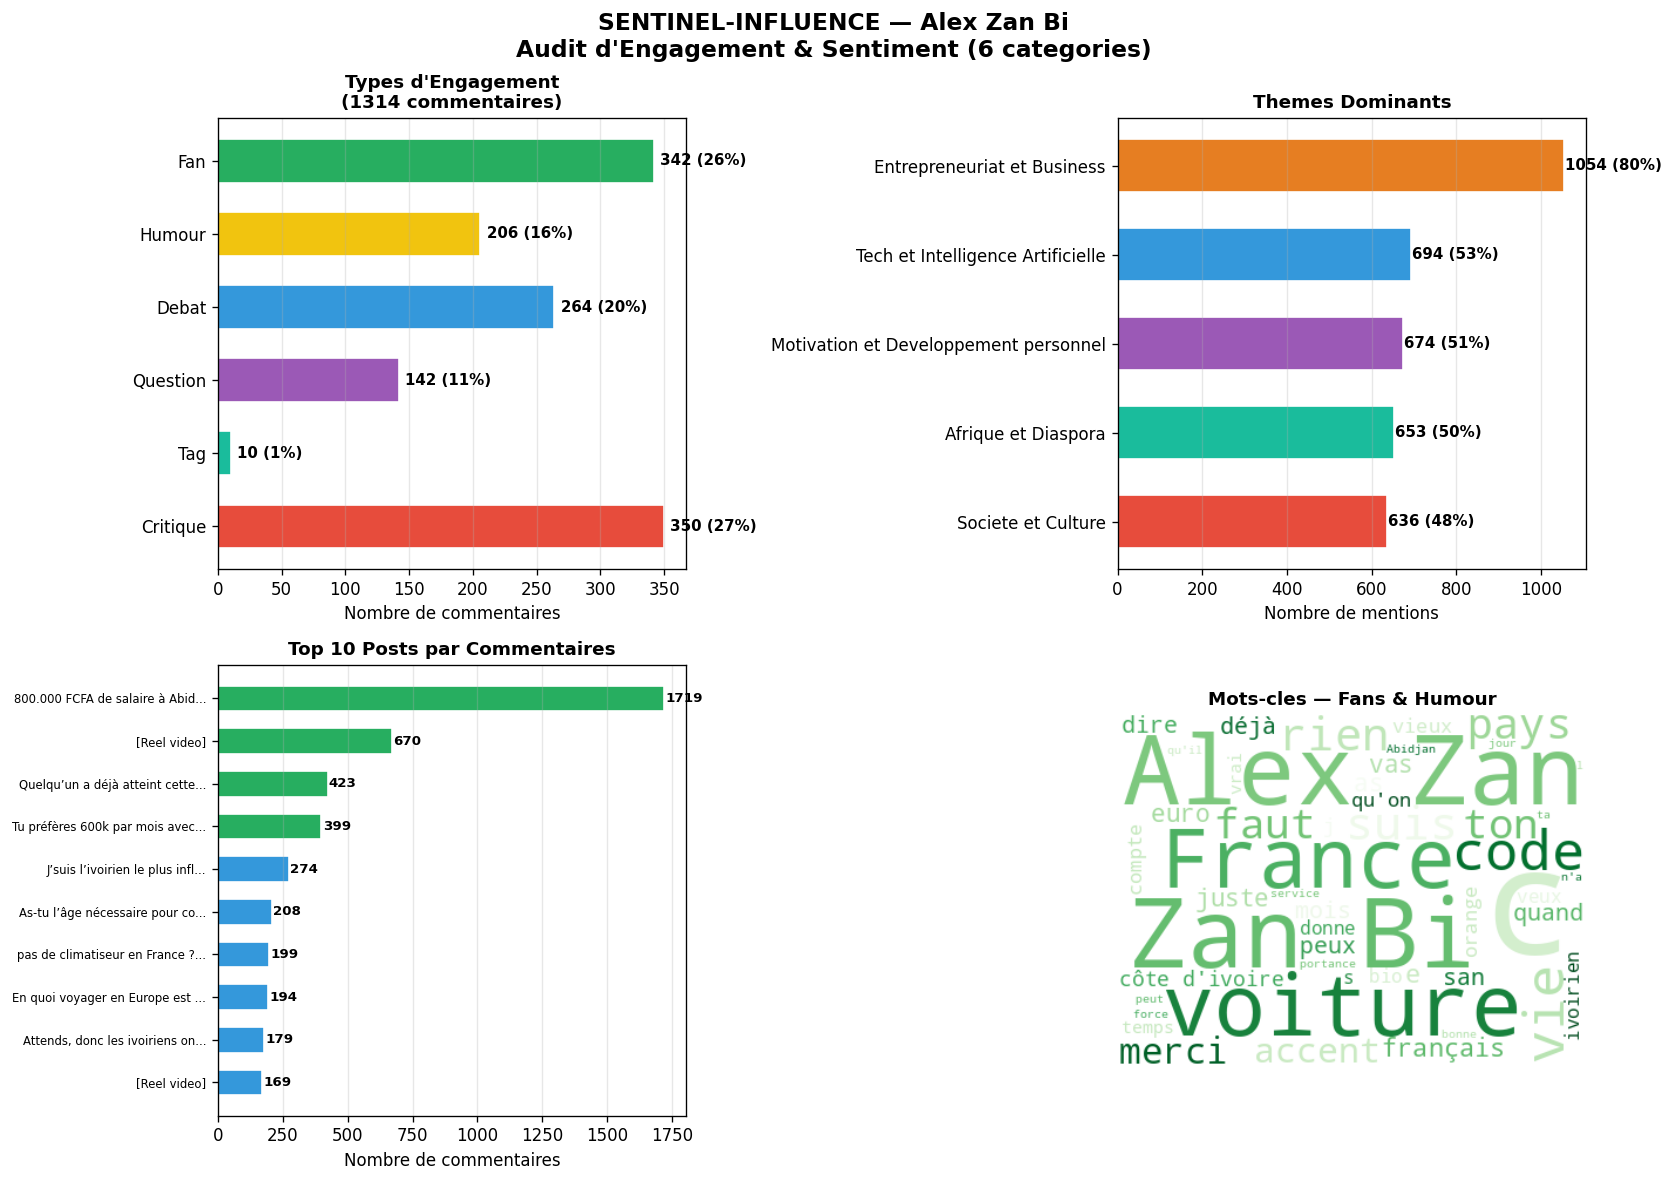


Graphique sauvegarde : sentinel_influence_dashboard.png


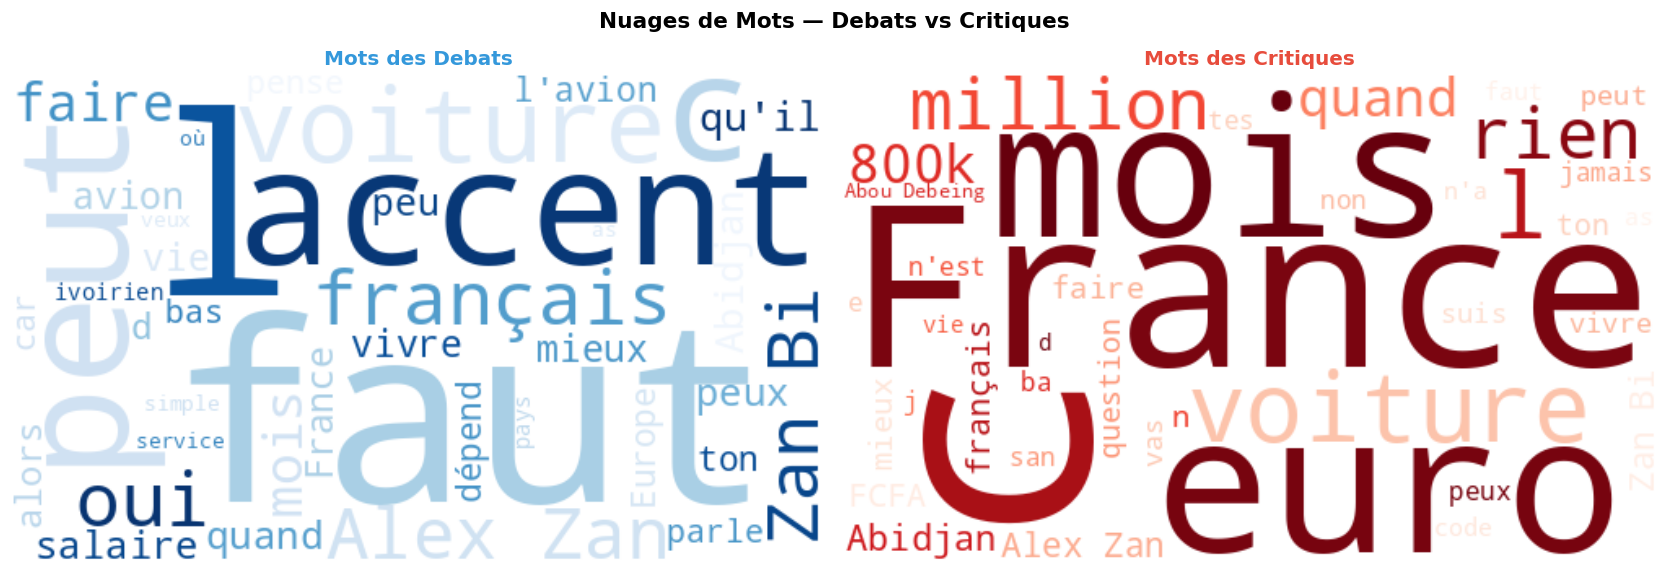

Graphique sauvegarde : sentinel_influence_wordclouds.png


In [13]:
# ============================================================
# BLOC 8 — Graphiques pour le rapport (grille 6 categories)
# ============================================================
# POURQUOI : visualiser les 6 types d'engagement au lieu du
# Positif/Neutre/Negatif classique. Chaque graphique est adapte
# pour montrer la richesse des interactions de la communaute.
# COMMENT : 4 visuels — repartition 6 categories, themes,
# engagement par post, nuage de mots par categorie.

!pip install wordcloud -q

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"SENTINEL-INFLUENCE — {NOM_INFLUENCEUR}\nAudit d'Engagement & Sentiment (6 categories)",
             fontsize=14, fontweight="bold")

# --- Palette de couleurs pour les 6 categories ---
couleurs_6 = {
    "Fan":      "#27ae60",   # vert — soutien
    "Debat":    "#3498db",   # bleu — opinion argumentee
    "Humour":   "#f1c40f",   # jaune — rire, complicite
    "Question": "#9b59b6",   # violet — curiosite
    "Tag":      "#1abc9c",   # turquoise — amplification
    "Critique": "#e74c3c",   # rouge — negativite
}

# ============================================================
# 1. REPARTITION DES 6 CATEGORIES (barres horizontales)
# ============================================================
ax1 = axes[0, 0]
sent_counts = comments_avec_texte["sentiment_label"].value_counts()

# Trier dans l'ordre logique : Fan > Humour > Debat > Question > Tag > Critique
ordre = ["Fan", "Humour", "Debat", "Question", "Tag", "Critique"]
sent_sorted = sent_counts.reindex([o for o in ordre if o in sent_counts.index]).dropna()

bars1 = ax1.barh(
    sent_sorted.index[::-1],
    sent_sorted.values[::-1],
    color=[couleurs_6.get(s, "gray") for s in sent_sorted.index[::-1]],
    height=0.6,
    edgecolor="white"
)

for bar, val in zip(bars1, sent_sorted.values[::-1]):
    pct = val / len(comments_avec_texte) * 100
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"{val} ({pct:.0f}%)", va="center", fontweight="bold", fontsize=9)

ax1.set_title(f"Types d'Engagement\n({len(comments_avec_texte)} commentaires)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Nombre de commentaires")
ax1.grid(axis="x", alpha=0.3)

# ============================================================
# 2. THEMES LES PLUS MENTIONNES
# ============================================================
ax2 = axes[0, 1]
themes_df_plot = pd.DataFrame(all_themes.most_common(), columns=["Theme", "Count"])
# Exclure "Non classe" si present
themes_df_plot = themes_df_plot[~themes_df_plot["Theme"].isin(["Non classe"])]

couleurs_themes = ["#e67e22", "#3498db", "#9b59b6", "#1abc9c", "#e74c3c", "#95a5a6"]
bars2 = ax2.barh(
    themes_df_plot["Theme"][::-1],
    themes_df_plot["Count"][::-1],
    color=couleurs_themes[:len(themes_df_plot)][::-1],
    height=0.6,
    edgecolor="white"
)

for bar, val in zip(bars2, themes_df_plot["Count"][::-1]):
    pct = val / len(comments_avec_texte) * 100
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{val} ({pct:.0f}%)", va="center", fontweight="bold", fontsize=9)

ax2.set_title("Themes Dominants", fontsize=11, fontweight="bold")
ax2.set_xlabel("Nombre de mentions")
ax2.grid(axis="x", alpha=0.3)

# ============================================================
# 3. ENGAGEMENT PAR POST (Top 10) — colore par taux Fan vs Critique
# ============================================================
ax3 = axes[1, 0]
top_10_posts = posts_df.nlargest(10, "comments")

labels_court = []
for t in top_10_posts["text"]:
    if pd.notna(t) and str(t) != "nan":
        labels_court.append(str(t)[:30].replace("\n", " ") + "...")
    else:
        labels_court.append("[Reel video]")

# Couleur par volume de commentaires
bar_colors = []
for c in top_10_posts["comments"]:
    if c > 300:
        bar_colors.append("#27ae60")   # viral — vert
    elif c > 150:
        bar_colors.append("#3498db")   # fort — bleu
    else:
        bar_colors.append("#f39c12")   # moyen — orange

bars3 = ax3.barh(range(len(labels_court)), top_10_posts["comments"].values,
                 color=bar_colors, height=0.6, edgecolor="white")
ax3.set_yticks(range(len(labels_court)))
ax3.set_yticklabels(labels_court, fontsize=7)
ax3.invert_yaxis()

for bar, val in zip(bars3, top_10_posts["comments"].values):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=8, fontweight="bold")

ax3.set_title("Top 10 Posts par Commentaires", fontsize=11, fontweight="bold")
ax3.set_xlabel("Nombre de commentaires")
ax3.grid(axis="x", alpha=0.3)

# ============================================================
# 4. NUAGE DE MOTS — Fan vs Critique (2 nuages superposes)
# ============================================================
ax4 = axes[1, 1]

stopwords_fr = {
    "de", "le", "la", "les", "du", "des", "un", "une", "et", "en",
    "est", "que", "qui", "dans", "pour", "pas", "sur", "au", "avec",
    "ce", "il", "se", "ne", "nous", "mais", "plus", "son", "sont",
    "par", "a", "je", "on", "c'est", "très", "tres", "j'ai", "aussi",
    "tout", "bien", "y", "vous", "cette", "ses", "leur", "mon", "ma",
    "ai", "si", "bon", "fait", "comme", "ou", "moi", "toi", "ça",
    "ca", "là", "tu", "te", "me", "ya", "va", "dit", "même", "meme",
    "quoi", "donc", "ici", "hein", "the", "and", "is", "to", "of",
    "it", "you", "not", "can", "has", "à", "qu", "être", "etre",
    "avoir", "sa", "ces", "ceux", "elle", "elles", "ils", "ont"
}

# Combiner Fan + Humour pour le nuage (les forces vives)
texte_positif = " ".join(
    comments_avec_texte[
        comments_avec_texte["sentiment_label"].isin(["Fan", "Humour"])
    ]["text"].dropna().tolist()
)

if texte_positif.strip():
    wc = WordCloud(
        width=400, height=300,
        background_color="white",
        colormap="Greens",
        max_words=50,
        stopwords=stopwords_fr
    ).generate(texte_positif)
    ax4.imshow(wc, interpolation="bilinear")
    ax4.set_title("Mots-cles — Fans & Humour", fontsize=11, fontweight="bold")
else:
    ax4.text(0.5, 0.5, "Pas assez de donnees", ha="center", va="center")
    ax4.set_title("Mots-cles — Fans & Humour")

ax4.axis("off")

plt.tight_layout()
plt.savefig("sentinel_influence_dashboard.png", bbox_inches="tight")
plt.show()
print("\nGraphique sauvegarde : sentinel_influence_dashboard.png")

# ============================================================
# GRAPHIQUE BONUS — Nuage de mots Debat + Critique (separe)
# ============================================================
fig2, (ax_deb, ax_crit) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Nuages de Mots — Debats vs Critiques", fontsize=13, fontweight="bold")

# Debat
texte_debat = " ".join(
    comments_avec_texte[
        comments_avec_texte["sentiment_label"] == "Debat"
    ]["text"].dropna().tolist()
)
if texte_debat.strip():
    wc_d = WordCloud(width=500, height=300, background_color="white",
                     colormap="Blues", max_words=40, stopwords=stopwords_fr).generate(texte_debat)
    ax_deb.imshow(wc_d, interpolation="bilinear")
ax_deb.set_title("Mots des Debats", fontweight="bold", color="#3498db")
ax_deb.axis("off")

# Critique
texte_critique = " ".join(
    comments_avec_texte[
        comments_avec_texte["sentiment_label"] == "Critique"
    ]["text"].dropna().tolist()
)
if texte_critique.strip():
    wc_c = WordCloud(width=500, height=300, background_color="white",
                     colormap="Reds", max_words=40, stopwords=stopwords_fr).generate(texte_critique)
    ax_crit.imshow(wc_c, interpolation="bilinear")
else:
    ax_crit.text(0.5, 0.5, "Tres peu de critiques\n(communaute saine !)",
                 ha="center", va="center", fontsize=12, color="#27ae60")
ax_crit.set_title("Mots des Critiques", fontweight="bold", color="#e74c3c")
ax_crit.axis("off")

plt.tight_layout()
plt.savefig("sentinel_influence_wordclouds.png", bbox_inches="tight")
plt.show()
print("Graphique sauvegarde : sentinel_influence_wordclouds.png")

In [14]:
# ============================================================
# BLOC 9 — Resume par theme : positivite et polarisation
# ============================================================
# POURQUOI : identifier quels themes generent le plus de
# positivite vs le plus de negativite/debat. Ca determine
# les recommandations strategiques pour l'influenceur.
# COMMENT : on eclate les themes (un par ligne), on calcule
# le taux de positivite/negativite par theme.

# --- Eclater les themes ---
rows_eclates = []
for _, row in comments_avec_texte.iterrows():
    for theme in row["themes"]:
        rows_eclates.append({
            "theme": theme,
            "sentiment_label": row["sentiment_label"],
            "sentiment_score": row["sentiment_score"],
            "likesCount": row["likesCount"],
        })

df_themes_eclate = pd.DataFrame(rows_eclates)

# --- Resume par theme ---
resume_themes = df_themes_eclate.groupby("theme").agg(
    mentions      = ("theme", "count"),
    pct_positif   = ("sentiment_label", lambda x: (x == "Positif").mean() * 100),
    pct_neutre    = ("sentiment_label", lambda x: (x == "Neutre").mean() * 100),
    pct_debat     = ("sentiment_label", lambda x: (x == "Debat").mean() * 100),
    pct_negatif   = ("sentiment_label", lambda x: (x == "Negatif").mean() * 100),
    score_moyen   = ("sentiment_score", "mean"),
).round(2).sort_values("pct_positif", ascending=False)

print(f"{'='*70}")
print(f"RESUME PAR THEME — TAUX DE POSITIVITE ET POLARISATION")
print(f"{'='*70}")
print(resume_themes.to_string())

# --- Themes les plus engageants ---
print(f"\n\n🟢 THEMES LES PLUS POSITIFS :")
top_positifs = resume_themes.head(3)
for i, (theme, row) in enumerate(top_positifs.iterrows(), 1):
    print(f"  {i}. {theme} ({row['pct_positif']:.0f}% positif, "
          f"{int(row['mentions'])} mentions)")

# --- Themes les plus polarisants ---
print(f"\n🔴 THEMES LES PLUS POLARISANTS :")
top_polar = resume_themes.sort_values("pct_negatif", ascending=False).head(3)
for i, (theme, row) in enumerate(top_polar.iterrows(), 1):
    print(f"  {i}. {theme} ({row['pct_negatif']:.0f}% negatif, "
          f"{row['pct_debat']:.0f}% debat, {int(row['mentions'])} mentions)")

RESUME PAR THEME — TAUX DE POSITIVITE ET POLARISATION
                                       mentions  pct_positif  pct_neutre  pct_debat  pct_negatif  score_moyen
theme                                                                                                        
Afrique et Diaspora                         653          0.0         0.0      21.29          0.0         2.71
Entrepreneuriat et Business                1054          0.0         0.0      20.49          0.0         2.93
Motivation et Developpement personnel       674          0.0         0.0      20.47          0.0         2.97
Societe et Culture                          636          0.0         0.0      21.86          0.0         2.97
Tech et Intelligence Artificielle           694          0.0         0.0      19.31          0.0         2.77


🟢 THEMES LES PLUS POSITIFS :
  1. Afrique et Diaspora (0% positif, 653 mentions)
  2. Entrepreneuriat et Business (0% positif, 1054 mentions)
  3. Motivation et Developpement

In [16]:
# ============================================================
# BLOC 10 — Sauvegarde complete des resultats
# ============================================================
# POURQUOI : conserver toutes les donnees enrichies pour le
# rapport PDF et pour une utilisation future (dashboard, etc.).
# COMMENT : export CSV + Excel du DataFrame enrichi.

# --- Convertir les listes de themes en string pour l'export ---
comments_avec_texte["themes_str"] = comments_avec_texte["themes"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
)

# --- Rendre la colonne 'date' timezone-naive pour l'export Excel ---
if "date" in comments_avec_texte.columns and comments_avec_texte["date"].dt.tz is not None:
    comments_avec_texte["date"] = comments_avec_texte["date"].dt.tz_localize(None)

# --- Export ---
comments_avec_texte.to_csv("influence_comments_analyse.csv", index=False)
comments_avec_texte.to_excel("influence_comments_analyse.xlsx", index=False)
posts_engagement.to_csv("influence_posts_engagement.csv", index=False)
fan_analysis.to_csv("influence_fans_analysis.csv", index=False)

print(f"{'='*60}")
print(f"SENTINEL-INFLUENCE — RESUME DE L'AUDIT")
print(f"{'='*60}")
print(f"Profil            : {NOM_INFLUENCEUR}")
print(f"Posts analyses     : {len(posts_df)}")
print(f"Commentaires NLP   : {len(comments_avec_texte)}")
print(f"Commentateurs      : {comments_avec_texte['profileName'].nunique()}")
print(f"Sentiment positif  : {(comments_avec_texte['sentiment_label']=='Positif').mean()*100:.0f}%")
print(f"Sentiment negatif  : {(comments_avec_texte['sentiment_label']=='Negatif').mean()*100:.1f}%")
print(f"Super fans         : {len(super_fans)}")
print(f"Haters recurrents  : {len(haters)}")
print(f"Theme dominant     : {all_themes.most_common(1)[0][0]}")
print(f"\nFichiers sauvegardes :")
print(f"  influence_comments_analyse.csv / .xlsx")
print(f"  influence_posts_engagement.csv")
print(f"  influence_fans_analysis.csv")
print(f"  sentinel_influence_dashboard.png")


SENTINEL-INFLUENCE — RESUME DE L'AUDIT
Profil            : Alex Zan Bi
Posts analyses     : 100
Commentaires NLP   : 1314
Commentateurs      : 959
Sentiment positif  : 0%
Sentiment negatif  : 0.0%
Super fans         : 6
Haters recurrents  : 26
Theme dominant     : Entrepreneuriat et Business

Fichiers sauvegardes :
  influence_comments_analyse.csv / .xlsx
  influence_posts_engagement.csv
  influence_fans_analysis.csv
  sentinel_influence_dashboard.png
